# 1. Pengumpulan Data Saham / Stock Data Collection



**Objective:**
This notebook aims to collect historical stock price data using the `yfinance` library.

**Steps:**
1.  Import the necessary libraries (`yfinance`, `pandas`).
2.  Define the stock ticker and the desired time period.
3.  Download the data from Yahoo Finance.
4.  Save the downloaded data to a CSV file in the `data/` folder for use in subsequent notebooks.

=============================================================

**Tujuan:**
Notebook ini bertujuan untuk mengumpulkan data harga saham historis menggunakan pustaka `yfinance`.

**Langkah-langkah:**
1.  Mengimpor pustaka yang diperlukan (`yfinance`, `pandas`).
2.  Menentukan ticker saham dan periode waktu yang diinginkan.
3.  Mengunduh data dari Yahoo Finance.
4.  Menyimpan data yang telah diunduh ke dalam file CSV di dalam folder `data/` untuk digunakan pada notebook selanjutnya.

## Question that I want to answer along the way

(I'll add more along the way too, i got those question from kaggle)

1. What was the change in price of the stock over time?
2. What was the daily return of the stock on average?
3. What was the moving average of the various stocks?
4. What was the correlation between different stocks'?
5. How much value do we put at risk by investing in a particular stock?
6. How can we attempt to predict future stock behavior? (Predicting the closing price stock price of APPLE inc using LSTM)
7. Trying to predict the closing price for the next 2 days (AAPL)

### Getting the Data

We will get our stock data from the Yahoo Finance website. Yahoo Finance is a rich resource of financial market data and tools to find compelling investments. To get the data from Yahoo Finance, we will be using yfinance library which offers a threaded and Pythonic way to download market data from Yahoo. 

In [49]:
import pandas as pd
import numpy as np
from datetime import datetime
import os

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# For reading stock data from yahoo
from pandas_datareader.data import DataReader
import yfinance as yf
from pandas_datareader import data as pdr




### For stocks, I am going to use 2 US stocks and 2 Indonesia stocks. 


US Stocks : Apple Inc. (AAPL), Google (GOOG)

Indonesia Stocks : PT Bank Central Asia (BBCA.JK), PT Bank Rakyat Indonesia (BBRI.JK)

In [50]:
"""
yf.pdr_override() <==== not needed with latest version of yfinance
that override method is not needed now, as the latest version of yfinance

"""

# stock i will use for this project.

stock_list = ['AAPL', 'GOOG', 'BBCA.JK', 'BBRI.JK']

# Set the time period for data collection
end = datetime(2025, 8, 28)
start = datetime(2023, 8, 28)

# Download data and store in a dictionary
stock_data = {}
for stock in stock_list:
    stock_data[stock] = yf.download(stock, start, end, auto_adjust=False)

company_name_map = {
    'AAPL': 'Apple Inc.',
    'GOOG': 'Google',
    'BBCA.JK': 'PT Bank Central Asia Tbk',
    'BBRI.JK': 'PT Bank Rakyat Indonesia Tbk'
}

# Combine all data into a single DataFrame
df_list = []
for ticker, df_stock in stock_data.items():
    df_stock['company_name'] = company_name_map[ticker]
    df_stock['ticker'] = ticker
    df_list.append(df_stock)

df = pd.concat(df_list, axis=0)
df.tail()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume,company_name,ticker,Adj Close,Close,...,High,Low,Open,Volume,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,,,GOOG,GOOG,...,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK
Date,,,,,,,,,,,,,,,,,,,,,
2025-08-21,NaN,NaN,NaN,NaN,NaN,NaN,PT Bank Rakyat Indonesia Tbk,BBRI.JK,NaN,NaN,...,NaN,NaN,NaN,NaN,4150.0,4150.0,4170.0,4090.0,4160.0,112477700.0
2025-08-22,NaN,NaN,NaN,NaN,NaN,NaN,PT Bank Rakyat Indonesia Tbk,BBRI.JK,NaN,NaN,...,NaN,NaN,NaN,NaN,4100.0,4100.0,4170.0,4100.0,4170.0,71971500.0
2025-08-25,NaN,NaN,NaN,NaN,NaN,NaN,PT Bank Rakyat Indonesia Tbk,BBRI.JK,NaN,NaN,...,NaN,NaN,NaN,NaN,4210.0,4210.0,4270.0,4170.0,4180.0,195322200.0
2025-08-26,NaN,NaN,NaN,NaN,NaN,NaN,PT Bank Rakyat Indonesia Tbk,BBRI.JK,NaN,NaN,...,NaN,NaN,NaN,NaN,4170.0,4170.0,4220.0,4170.0,4220.0,267465600.0
2025-08-27,NaN,NaN,NaN,NaN,NaN,NaN,PT Bank Rakyat Indonesia Tbk,BBRI.JK,NaN,NaN,...,NaN,NaN,NaN,NaN,4130.0,4130.0,4150.0,4070.0,4130.0,123874000.0


### Saving the data in a CSV file

In [51]:
# Save the DataFrame to a CSV file in the 'data' folder

# data_dir = '../data/raw'
# file_path = os.path.join(data_dir, 'historical_stock_data.csv')

# df.to_csv(file_path)
# print(f"Data berhasil disimpan ke: {file_path}")

### Descriptive Statistics about the data

.describe() generates descriptive statistics. Descriptive statistics include those that summarize the central tendency, dispersion, and shape of a dataset’s distribution, excluding NaN values.

since the data that i use is combined to one csv file this will be a bit long. bear with me Im new to this.


In [52]:
df[df['ticker'] == 'AAPL'].head(10)
df[df['ticker'] == 'AAPL'].describe()




Price,Adj Close,Close,High,Low,Open,Volume,Adj Close,Close,High,Low,...,High,Low,Open,Volume,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,GOOG,GOOG,GOOG,GOOG,...,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK
count,502.000000,502.000000,502.000000,502.000000,502.000000,5.020000e+02,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,205.063247,206.076375,208.000179,203.914382,205.839542,5.694120e+07,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,23.728036,23.484142,23.654268,23.158390,23.445394,2.650321e+07,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,163.823563,165.000000,166.399994,164.080002,165.350006,2.323470e+07,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,184.426086,185.987499,187.460003,183.837505,186.067497,4.248250e+07,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,206.457779,207.360001,209.794998,202.870003,206.229996,5.106845e+07,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,225.435818,226.452499,228.165001,224.010002,225.972500,6.253588e+07,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,258.103729,259.019989,260.100006,257.630005,258.190002,3.186799e+08,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
df[df['ticker'] == 'GOOG'].head(10)
df[df['ticker'] == 'GOOG'].describe()


Price,Adj Close,Close,High,Low,Open,Volume,Adj Close,Close,High,Low,...,High,Low,Open,Volume,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,GOOG,GOOG,GOOG,GOOG,...,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK
count,0.0,0.0,0.0,0.0,0.0,0.0,502.000000,502.000000,502.000000,502.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,163.949490,164.543307,166.269719,162.766410,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,20.619393,20.467761,20.697010,20.237758,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,122.670822,123.400002,124.440002,121.459999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,145.582138,146.422497,147.152500,144.869995,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,165.776939,166.029999,167.949997,164.504997,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,177.549442,178.147503,179.887505,176.105000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,209.160004,209.160004,211.089996,206.449997,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
df[df['ticker'] == 'BBCA.JK'].head(10)
df[df['ticker'] == 'BBCA.JK'].describe()


Price,Adj Close,Close,High,Low,Open,Volume,Adj Close,Close,High,Low,...,High,Low,Open,Volume,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,GOOG,GOOG,GOOG,GOOG,...,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,474.000000,474.000000,474.000000,4.740000e+02,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9532.489451,9372.151899,9452.478903,8.983476e+07,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,660.559716,662.136501,662.743373,6.371042e+07,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7950.000000,7275.000000,7400.000000,2.082770e+07,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9000.000000,8875.000000,8931.250000,5.587225e+07,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9550.000000,9362.500000,9462.500000,7.577965e+07,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10075.000000,9918.750000,10000.000000,1.009436e+08,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10950.000000,10775.000000,10900.000000,7.564316e+08,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
df[df['ticker'] == 'BBRI.JK'].head(10)
df[df['ticker'] == 'BBRI.JK'].describe()

Price,Adj Close,Close,High,Low,Open,Volume,Adj Close,Close,High,Low,...,High,Low,Open,Volume,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,GOOG,GOOG,GOOG,GOOG,...,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,474.000000,474.000000,474.000000,474.000000,474.000000,4.740000e+02
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4352.816749,4743.512658,4803.523207,4696.951477,4748.090717,2.212612e+08
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,525.402463,729.452902,728.637868,727.928974,727.571037,1.349465e+08
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3175.730469,3360.000000,3540.000000,3360.000000,3460.000000,3.712660e+07
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3907.075989,4100.000000,4160.000000,4070.000000,4102.500000,1.214974e+08
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4341.295410,4750.000000,4810.000000,4700.000000,4760.000000,1.913891e+08
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4688.507935,5300.000000,5368.750000,5250.000000,5318.750000,2.810994e+08
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5763.100098,6400.000000,6450.000000,6350.000000,6350.000000,1.000598e+09


as for all the describe that I do, I found something is different, which is the count or the total of the records for each stocks. for US stocks its 503.0 and for indonesia stocks its 475.0

this happend because the data that I get is for the last 2 year and no weekend and holiday is included and Indonesian and US stocks have different trading hours, different holidays. so it will be different because of those reasons.

In [56]:
df[df['ticker'] == 'AAPL'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502 entries, 2023-08-28 to 2025-08-27
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   (Adj Close, AAPL)     502 non-null    float64
 1   (Close, AAPL)         502 non-null    float64
 2   (High, AAPL)          502 non-null    float64
 3   (Low, AAPL)           502 non-null    float64
 4   (Open, AAPL)          502 non-null    float64
 5   (Volume, AAPL)        502 non-null    float64
 6   (company_name, )      502 non-null    object 
 7   (ticker, )            502 non-null    object 
 8   (Adj Close, GOOG)     0 non-null      float64
 9   (Close, GOOG)         0 non-null      float64
 10  (High, GOOG)          0 non-null      float64
 11  (Low, GOOG)           0 non-null      float64
 12  (Open, GOOG)          0 non-null      float64
 13  (Volume, GOOG)        0 non-null      float64
 14  (Adj Close, BBCA.JK)  0 non-null      float64
 15  (Clo

and I believe from the .info() that I do there is no null data for all the stocks. 

### Closing Price
The closing price is the last price at which the stock is traded during the regular trading day. A stock’s closing price is the standard benchmark used by investors to track its performance over time.

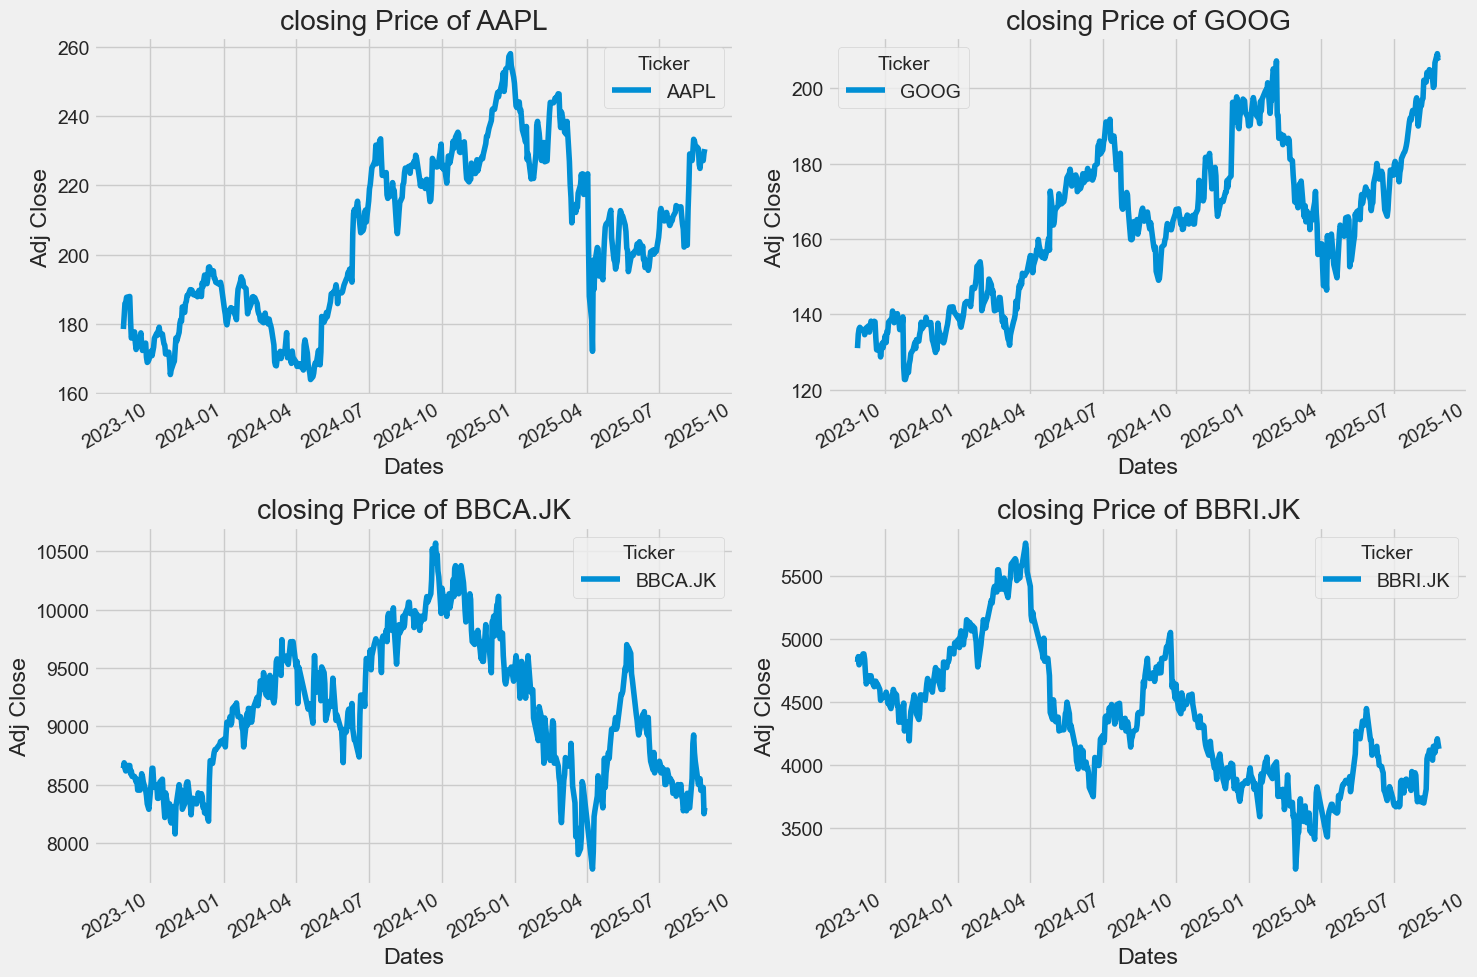

In [57]:
plt.figure(figsize = (15, 10))


for i, ticker in enumerate(stock_list, 1) : 
    ax = plt.subplot(2, 2, i)
    stock_data[ticker]['Adj Close'].plot(ax=ax)
    plt.ylabel('Adj Close')
    plt.xlabel('Dates')
    plt.title(f"closing Price of {ticker}")

plt.tight_layout()
plt.show()

### Volume of Sales
Volume is the amount of an asset or security that changes hands over some period of time, often over the course of a day. For instance, the stock trading volume would refer to the number of shares of security traded between its daily open and close. Trading volume, and changes to volume over the course of time, are important inputs for technical traders.

Volume adalah jumlah aset atau sekuritas yang berpindah tangan dalam periode waktu tertentu, sering kali dalam satu hari. Sebagai contoh, volume perdagangan saham mengacu pada jumlah lembar saham suatu sekuritas yang diperdagangkan antara waktu pembukaan dan penutupan harian. Volume perdagangan, serta perubahannya dari waktu ke waktu, adalah input penting bagi para trader teknikal

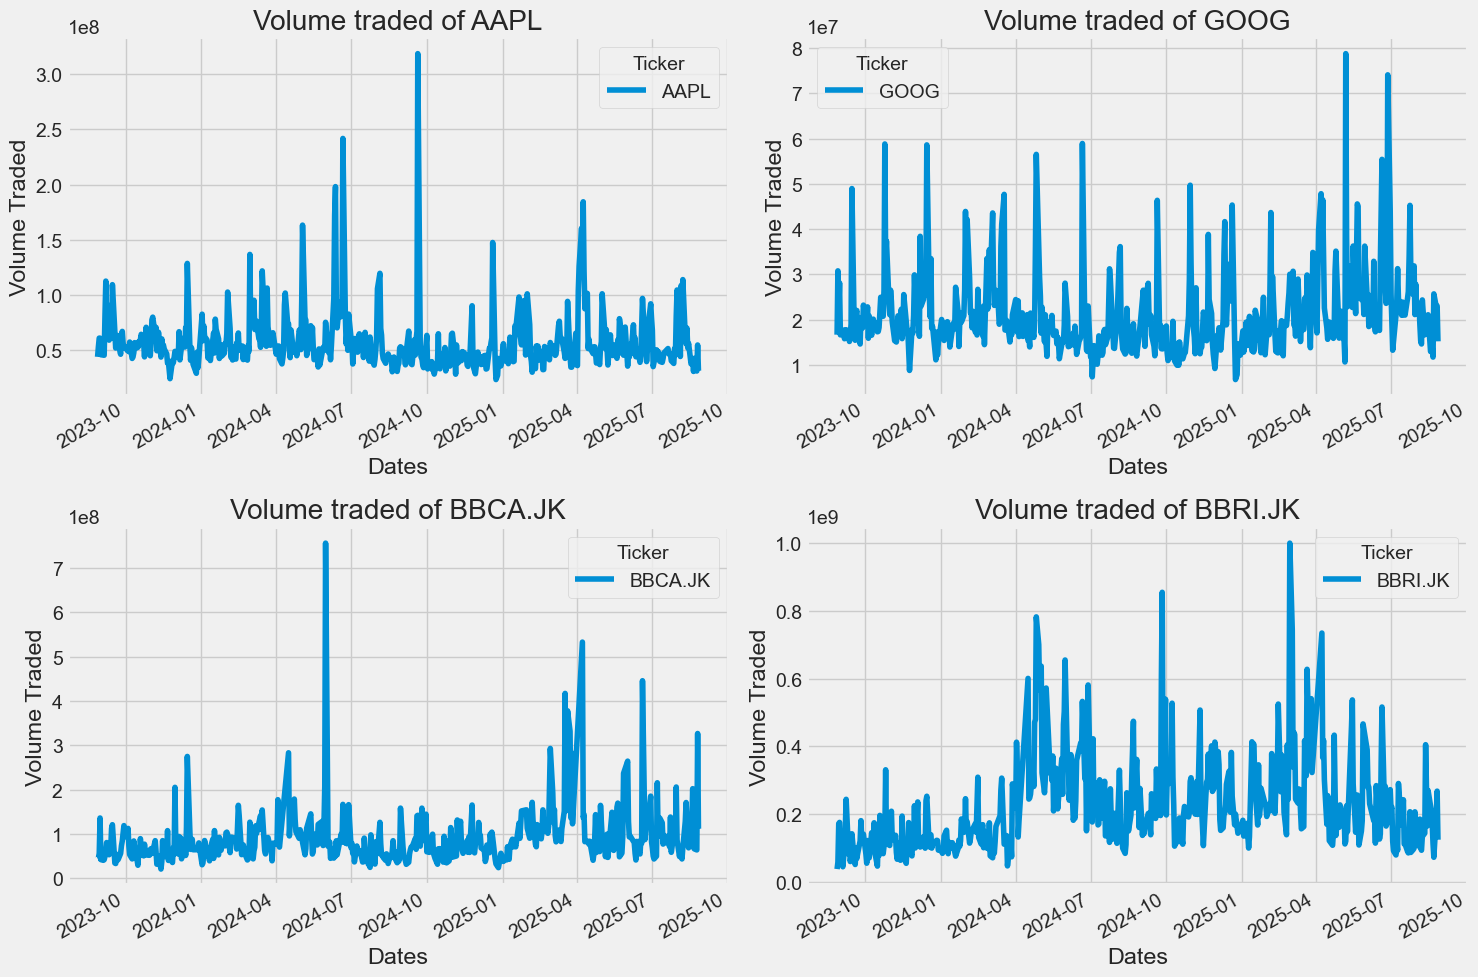

In [58]:
# lets see the volume traded for each stock
plt.figure(figsize = (15, 10))

for i, ticker in enumerate(stock_list, 1) :
    ax = plt.subplot(2, 2, i)
    stock_data[ticker]['Volume'].plot(ax=ax)
    plt.ylabel('Volume Traded')
    plt.xlabel('Dates')
    plt.title(f"Volume traded of {ticker}")

plt.tight_layout()
plt.show()

now that we've seen the closing price and volume traded each day for those stocks, next up we are going to calculate the moving average for each stock.

# 2. What was the moving average of the various stocks?
The moving average (MA) is a simple technical analysis tool that smooths out price data by creating a constantly updated average price. The average is taken over a specific period of time, like 10 days, 20 minutes, 30 weeks, or any time period the trader chooses

Moving Average atau rata rata bergerak/pergerakan adalah alat analisis teknikal yang digunakan untuk menghaluskan data harga saham dengan cara menghtiung rata rata harga saham selama waktu tertentu, seperti 10 hari, 20 menit, 30 minggu, atau periode waktu yang trader pilih.

In [59]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume,company_name,ticker,Adj Close,Close,...,High,Low,Open,Volume,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,,,GOOG,GOOG,...,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK
Date,,,,,,,,,,,,,,,,,,,,,
2023-08-28,178.442154,180.190002,180.589996,178.550003,180.089996,43820700.0,Apple Inc.,AAPL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08-29,182.334045,184.119995,184.899994,179.500000,179.699997,53003900.0,Apple Inc.,AAPL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08-30,185.829803,187.649994,187.850006,184.740005,184.940002,60813900.0,Apple Inc.,AAPL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08-31,186.047668,187.869995,189.119995,187.479996,187.839996,60794500.0,Apple Inc.,AAPL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-01,187.622253,189.460007,189.919998,188.279999,189.490005,45766500.0,Apple Inc.,AAPL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
AAPL = stock_data['AAPL'].copy()
GOOG = stock_data['GOOG'].copy()
BBCA = stock_data['BBCA.JK'].copy()
BBRI = stock_data['BBRI.JK'].copy()

company_list = [AAPL, GOOG, BBCA, BBRI]

ma_day = [10, 20, 50]
for ma in ma_day:
    for company in company_list:
        column_name = f"MA for {ma} days"
        company[column_name] = company['Adj Close'].rolling(ma).mean()


saving that data that i just seperate, into a seperate csv files. using Globals() might be sloppy but it works better if you want to use the data for visualization. since I combine all of it to the same dataframe i have to do that

In [61]:
"""
data_dir = '../data/processed'
os.makedirs(data_dir, exist_ok=True)

# Dictionary yang berisi DataFrame untuk setiap saham
company_dict = {
    'AAPL': AAPL,
    'GOOG': GOOG,
    'BBCA': BBCA,
    'BBRI': BBRI
}

for ticker, df_company in company_dict.items():
    file_path = os.path.join(data_dir, f'{ticker}with_MA.csv')
    df_company.to_csv(file_path)
    print(f"Data berhasil disimpan ke: {file_path}")

    """


'\ndata_dir = \'../data/processed\'\nos.makedirs(data_dir, exist_ok=True)\n\n# Dictionary yang berisi DataFrame untuk setiap saham\ncompany_dict = {\n    \'AAPL\': AAPL,\n    \'GOOG\': GOOG,\n    \'BBCA\': BBCA,\n    \'BBRI\': BBRI\n}\n\nfor ticker, df_company in company_dict.items():\n    file_path = os.path.join(data_dir, f\'{ticker}with_MA.csv\')\n    df_company.to_csv(file_path)\n    print(f"Data berhasil disimpan ke: {file_path}")\n\n    '

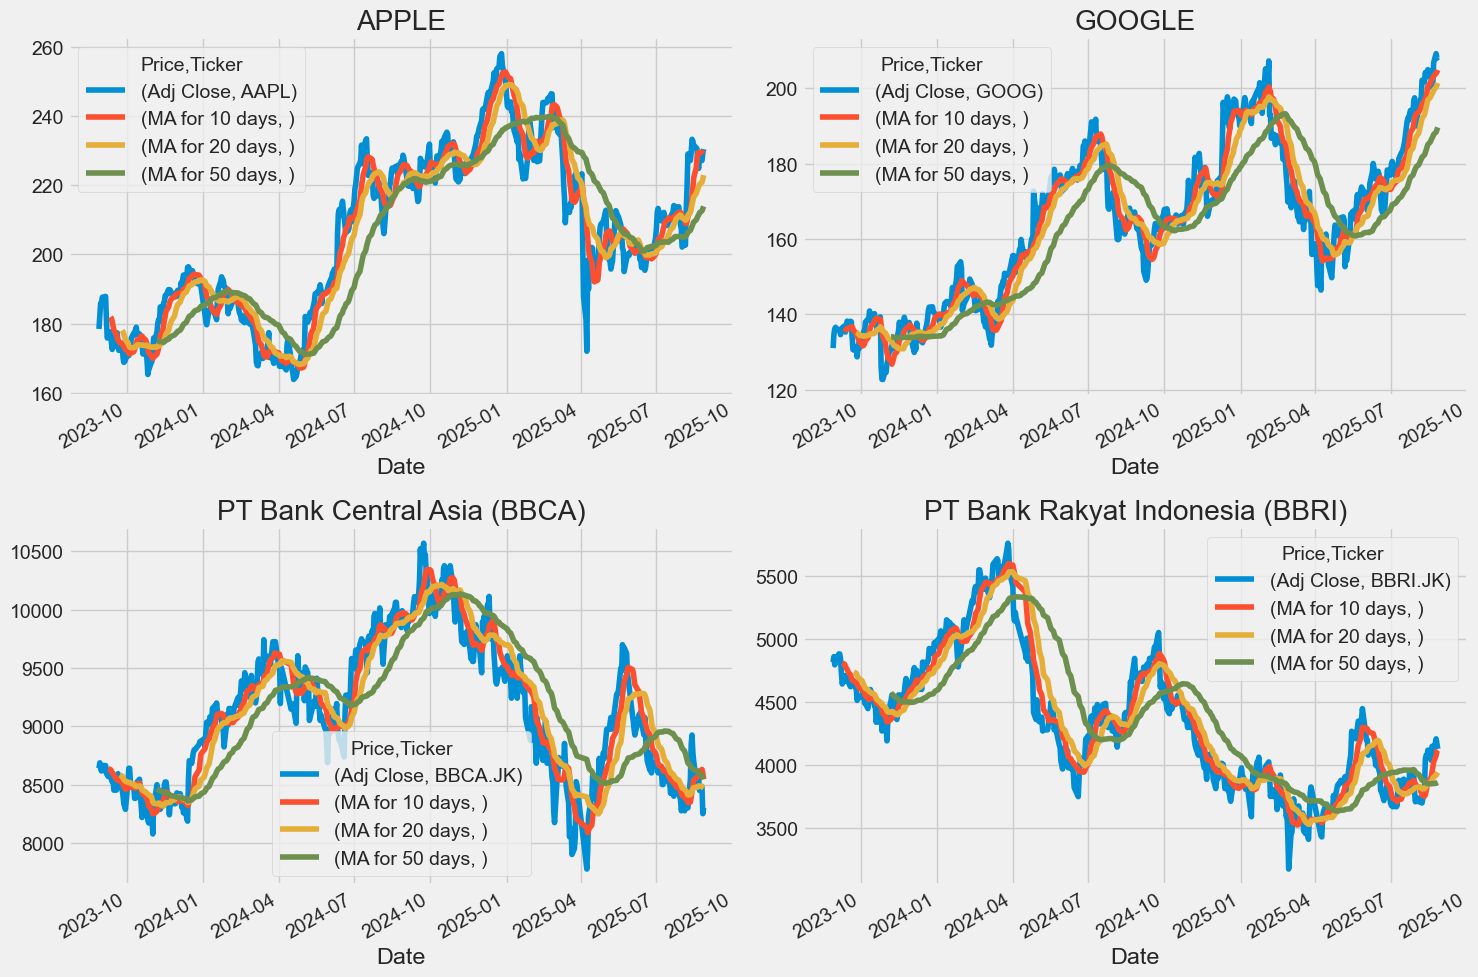

In [62]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15,10))

AAPL[['Adj Close','MA for 10 days','MA for 20 days','MA for 50 days']].plot(ax=axes[0,0])
axes[0,0].set_title('APPLE')

GOOG[['Adj Close','MA for 10 days','MA for 20 days','MA for 50 days']].plot(ax=axes[0,1])
axes[0,1].set_title('GOOGLE')

BBCA[['Adj Close','MA for 10 days','MA for 20 days','MA for 50 days']].plot(ax=axes[1,0])
axes[1,0].set_title('PT Bank Central Asia (BBCA)')

BBRI[['Adj Close','MA for 10 days','MA for 20 days','MA for 50 days']].plot(ax=axes[1,1])
axes[1,1].set_title('PT Bank Rakyat Indonesia (BBRI)')

plt.tight_layout()
plt.show()

from the graph above we can see the golden cross, death cross, and bullish and bearish candlestick patterns. we can see a clear trend for each stock.

# 3. What was the daily return of the stock on average?


in this point we are going to dive little bit deeper into the data. we are going to calculate the daily return of the stock on average.
We're now going to analyze the risk of the stock. In order to do so we'll need to take a closer look at the daily changes of the stock, and not just its absolute value

In [63]:
company_list = [AAPL, GOOG, BBCA, BBRI]

for dfc in company_list : 
    dfc.index = pd.to_datetime(dfc.index)
    dfc['Daily Return'] = dfc['Adj Close'].pct_change()


dfc.head()



Price,Adj Close,Close,High,Low,Open,Volume,company_name,ticker,MA for 10 days,MA for 20 days,MA for 50 days,Daily Return
Ticker,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,,,,,,
Date,,,,,,,,,,,,
2023-08-28,4818.837891,5550.0,5625.0,5550.0,5600.0,37126600,PT Bank Rakyat Indonesia Tbk,BBRI.JK,NaN,NaN,NaN,NaN
2023-08-29,4862.250977,5600.0,5600.0,5525.0,5525.0,57547200,PT Bank Rakyat Indonesia Tbk,BBRI.JK,NaN,NaN,NaN,0.009009
2023-08-30,4797.131348,5525.0,5600.0,5500.0,5600.0,171282700,PT Bank Rakyat Indonesia Tbk,BBRI.JK,NaN,NaN,NaN,-0.013393
2023-08-31,4818.837891,5550.0,5550.0,5475.0,5525.0,175088200,PT Bank Rakyat Indonesia Tbk,BBRI.JK,NaN,NaN,NaN,0.004525
2023-09-01,4840.543945,5575.0,5600.0,5525.0,5600.0,87366100,PT Bank Rakyat Indonesia Tbk,BBRI.JK,NaN,NaN,NaN,0.004504


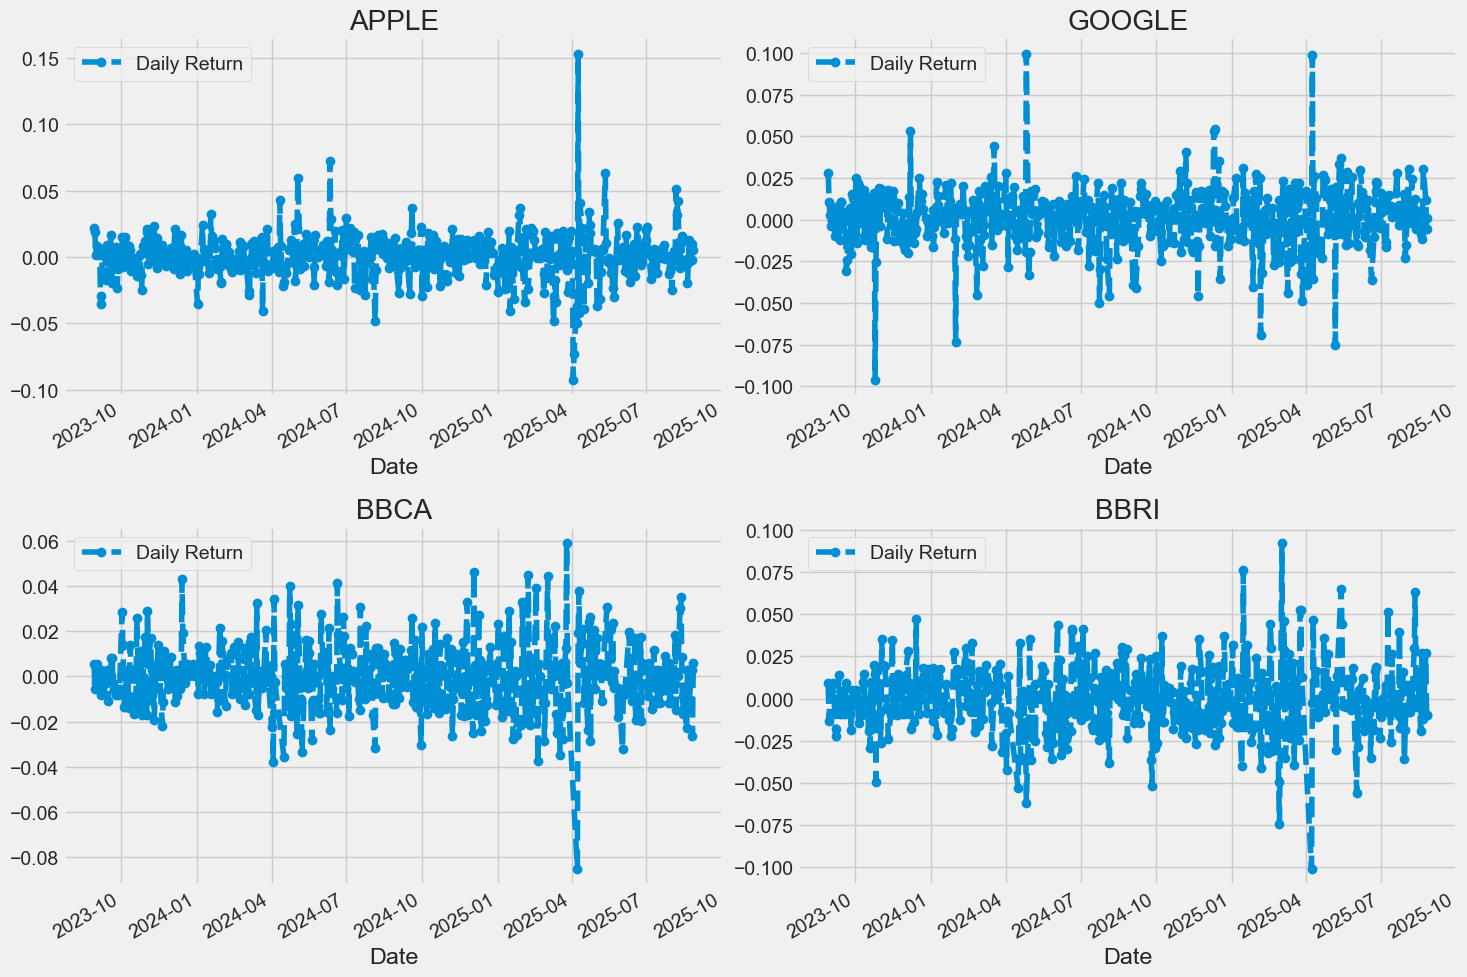

In [64]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15,10))

AAPL['Daily Return'].plot(ax=axes[0,0], legend=True, linestyle='--', marker='o')
axes[0,0].set_title('APPLE')

GOOG['Daily Return'].plot(ax=axes[0,1], legend=True, linestyle='--', marker='o')
axes[0,1].set_title('GOOGLE')

BBCA['Daily Return'].plot(ax=axes[1,0], legend=True, linestyle='--', marker='o')
axes[1,0].set_title('BBCA')

BBRI['Daily Return'].plot(ax=axes[1,1], legend=True, linestyle='--', marker='o')
axes[1,1].set_title('BBRI')

plt.tight_layout()
plt.show()

now that we see the daily return for each stock, now let's get an overall look at the average daily return using a histogram. We'll use seaborn to create both a histogram and kde plot on the same figure.

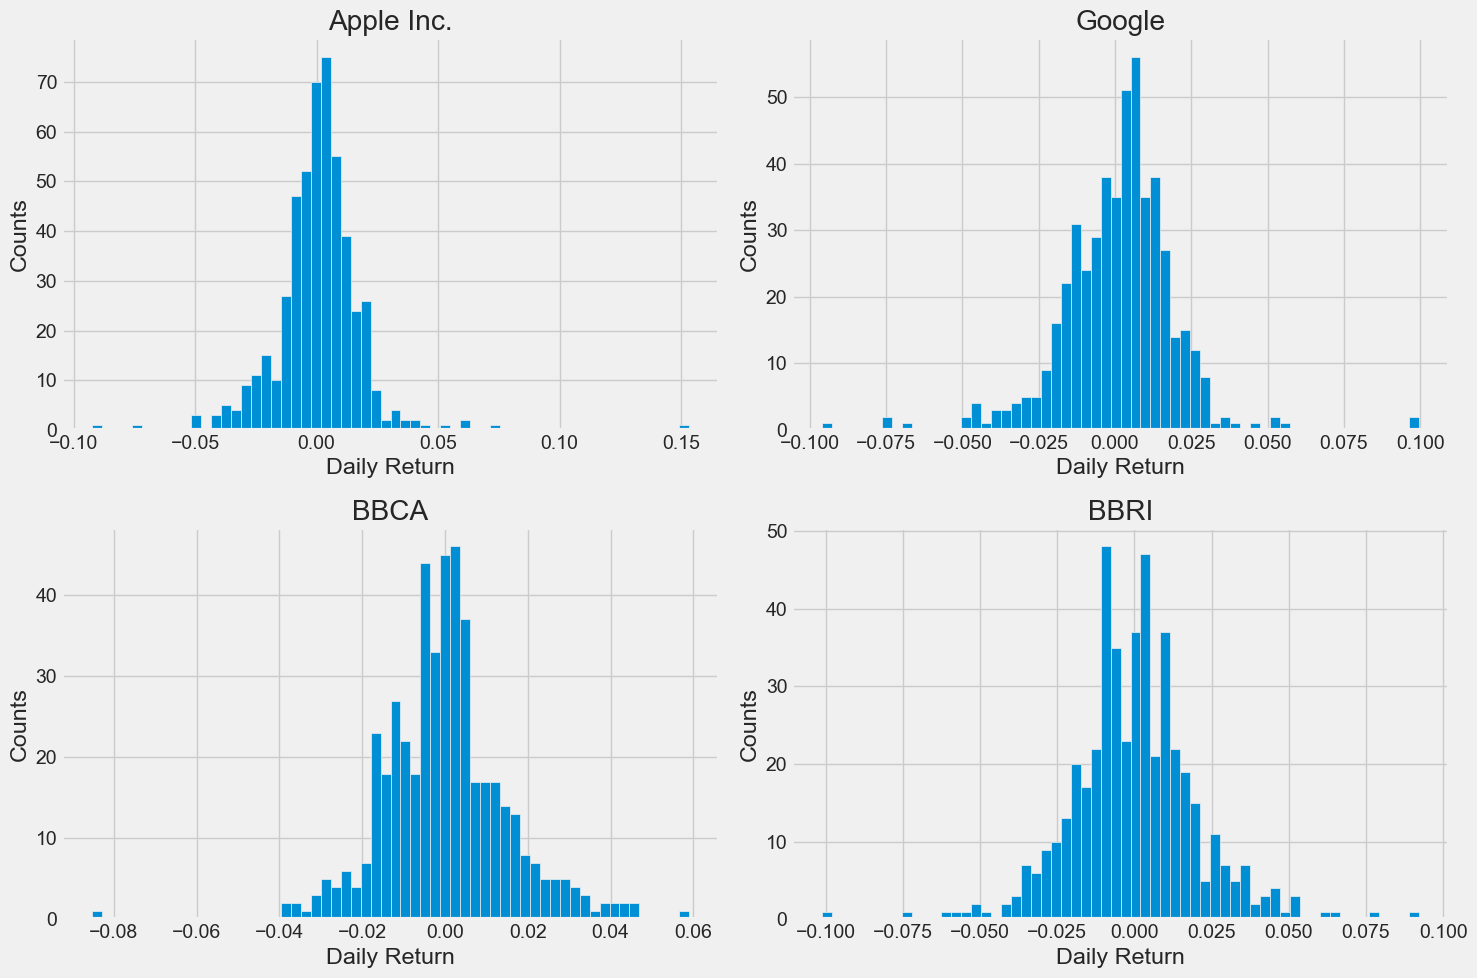

In [65]:
plt.figure(figsize = (15, 10))
company_name = ['Apple Inc.', 'Google', 'BBCA', 'BBRI']

for i, company in enumerate(company_list, 1 ) : 
    ax = plt.subplot(2, 2, i) 
    company['Daily Return'].hist(bins = 60, ax = ax)
    plt.xlabel("Daily Return")
    plt.ylabel("Counts")
    plt.title(f"{company_name[i - 1]}")

plt.tight_layout()


# 4. What was the correlation between different stocks closing prices?

Correlation is a statistic that measures the degree to which two variables move in relation to each other which has a value that must fall between -1.0 and +1.0. Correlation measures association, but doesn’t show if x causes y or vice versa — or if the association is caused by a third factor.

In [66]:
closing_df = df.pivot_table(index = df.index, columns='ticker', values= 'Adj Close')

closing_df.head()
# closing_df.to_csv('../data/processed/closing_df.csv')

#type(closing_df)

C:\Users\ANGELO\AppData\Local\Temp\ipykernel_16164\1209499059.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  closing_df = df.pivot_table(index = df.index, columns='ticker', values= 'Adj Close')


Ticker,AAPL,BBCA.JK,BBRI.JK,GOOG
ticker,AAPL,BBCA.JK,BBRI.JK,GOOG
Date,,,,
2023-08-28,178.442154,8639.810547,4818.837891,131.011261
2023-08-29,182.334045,8686.766602,4862.250977,134.689377
2023-08-30,185.829803,8639.810547,4797.131348,136.120865
2023-08-31,186.047668,8616.333008,4818.837891,136.538391
2023-09-01,187.622253,8663.289062,4840.543945,135.991638


In [67]:
closing_rets = closing_df.pct_change()
closing_rets = closing_rets.reset_index()
closing_rets.head()
# cek dulu kolomnya
# print(closing_rets.columns)

closing_rets.columns = ['Date'] + [col[0] for col in closing_rets.columns[1:]]
print(closing_rets.columns)


Index(['Date', 'AAPL', 'BBCA.JK', 'BBRI.JK', 'GOOG'], dtype='object')


C:\Users\ANGELO\AppData\Local\Temp\ipykernel_16164\3347711329.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  closing_rets = closing_df.pct_change()


need a bit of flatten for the columns names, now we are good.

now that we got the data, let's see the correlation between the stocks

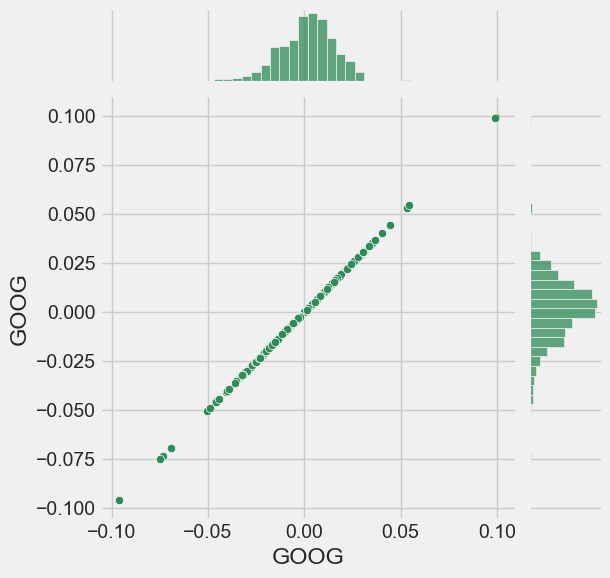

In [68]:
# Comparing Google to itself should show a perfectly linear relationship
sns.jointplot(x='GOOG', y='GOOG', data=closing_rets, kind='scatter', color='seagreen')

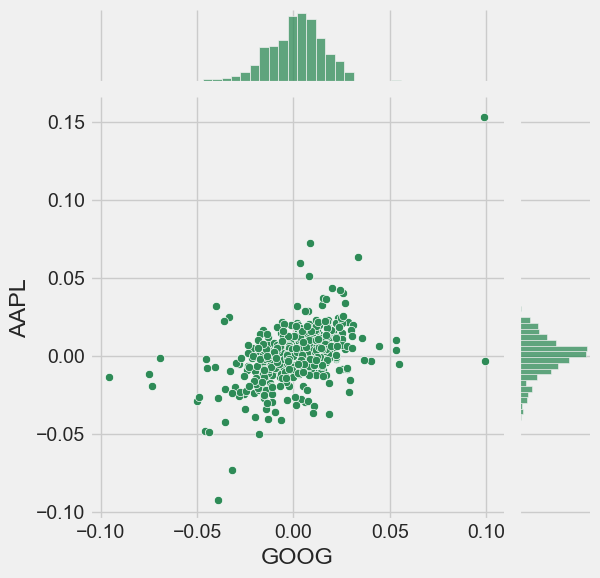

In [69]:
# next we compare Google to Apple
sns.jointplot(x='GOOG', y='AAPL', data=closing_rets, kind='scatter', color='seagreen') 

In [70]:
corr = closing_rets[['AAPL', 'GOOG']].corr()
print(corr)

          AAPL      GOOG
AAPL  1.000000  0.460421
GOOG  0.460421  1.000000


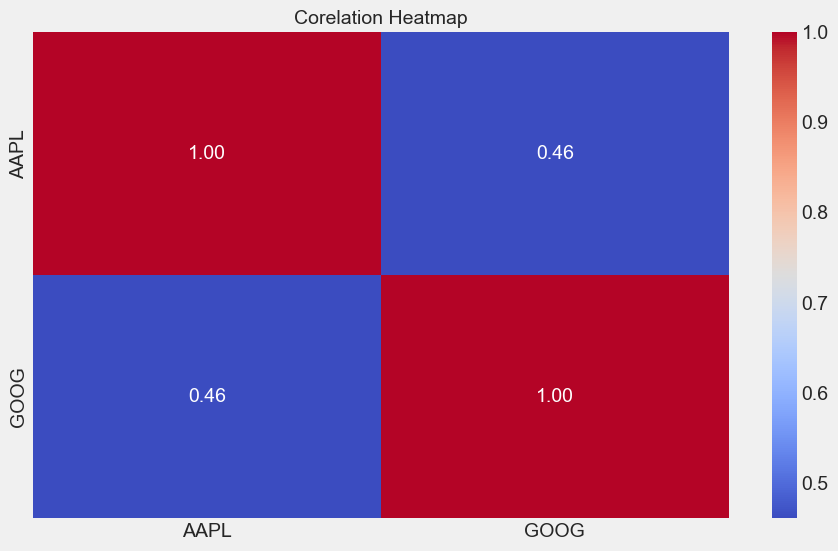

In [71]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corelation Heatmap", fontsize=14)
plt.show()

now that is APPLE with GOOGLE, how about the indonesian stocks? 

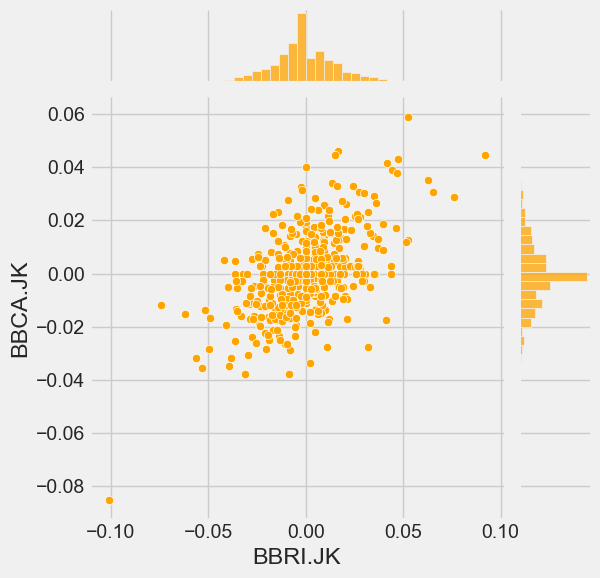

In [72]:
# lets try with the indonesian stocks BBRI and BBCA
sns.jointplot(x='BBRI.JK', y='BBCA.JK', data=closing_rets, kind='scatter', color='orange')

In [73]:
corr_indo = closing_rets[['BBCA.JK', 'BBRI.JK']].corr()
corr_indo

,BBCA.JK,BBRI.JK
BBCA.JK,1.000000,0.567753
BBRI.JK,0.567753,1.000000


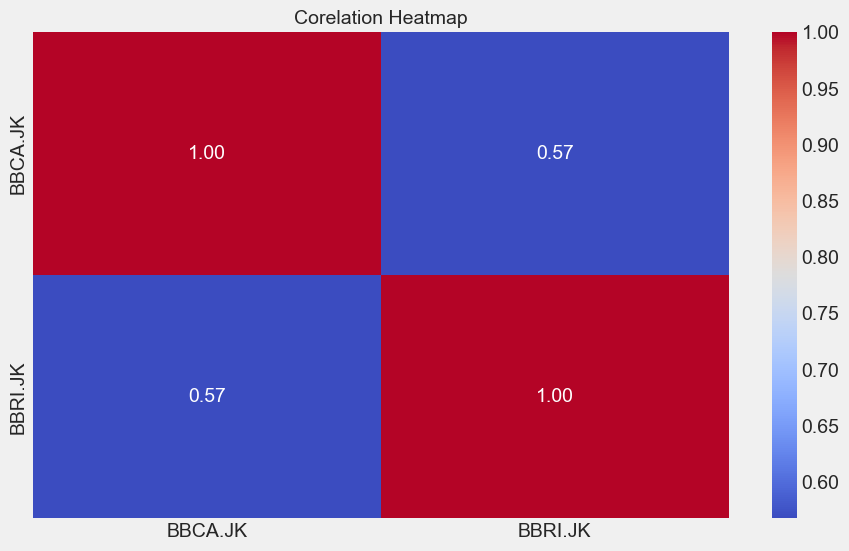

In [74]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_indo, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corelation Heatmap", fontsize=14)
plt.show()

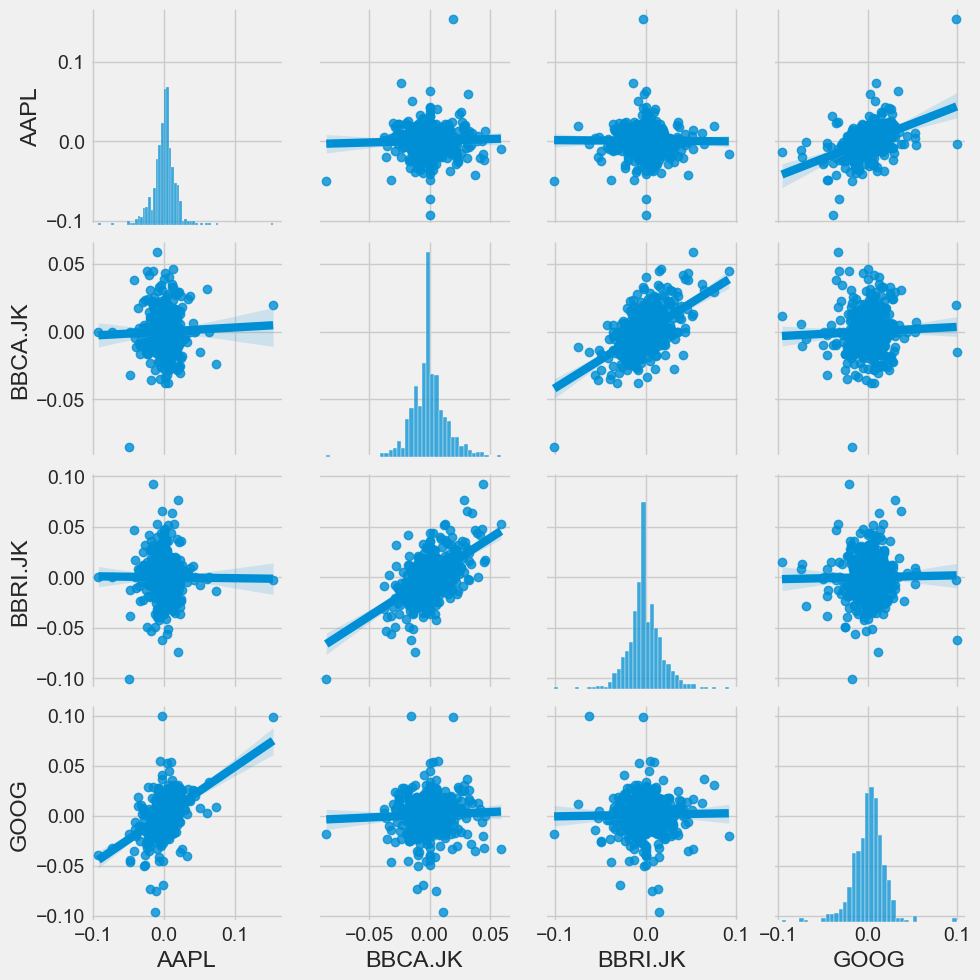

In [75]:
# We can simply call pairplot on our DataFrame for an automatic visual analysis 
# of all the comparisons

sns.pairplot(closing_rets, kind='reg')


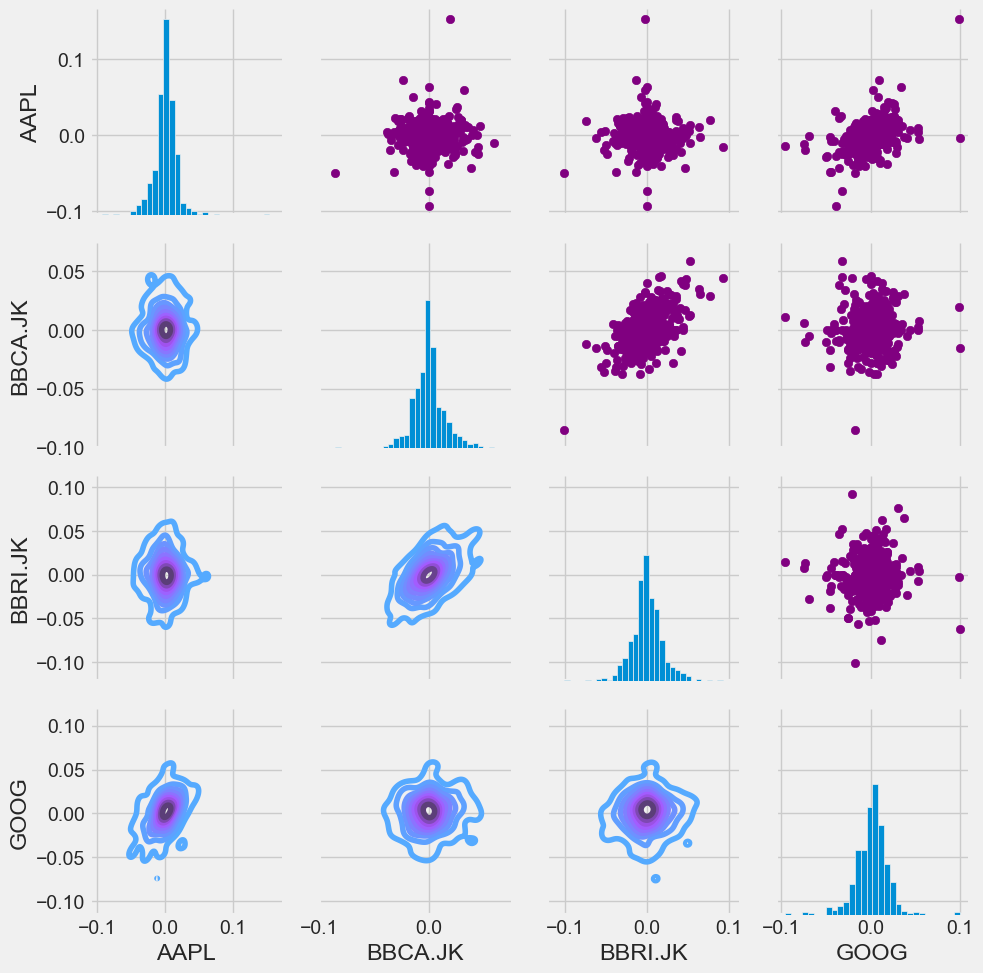

In [76]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
return_fig = sns.PairGrid(closing_rets.dropna())

# Using map_upper we can specify what the upper triangle will look like.
return_fig.map_upper(plt.scatter, color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde) 
# or the color map (BluePurple)
return_fig.map_lower(sns.kdeplot, cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
return_fig.map_diag(plt.hist, bins=30)

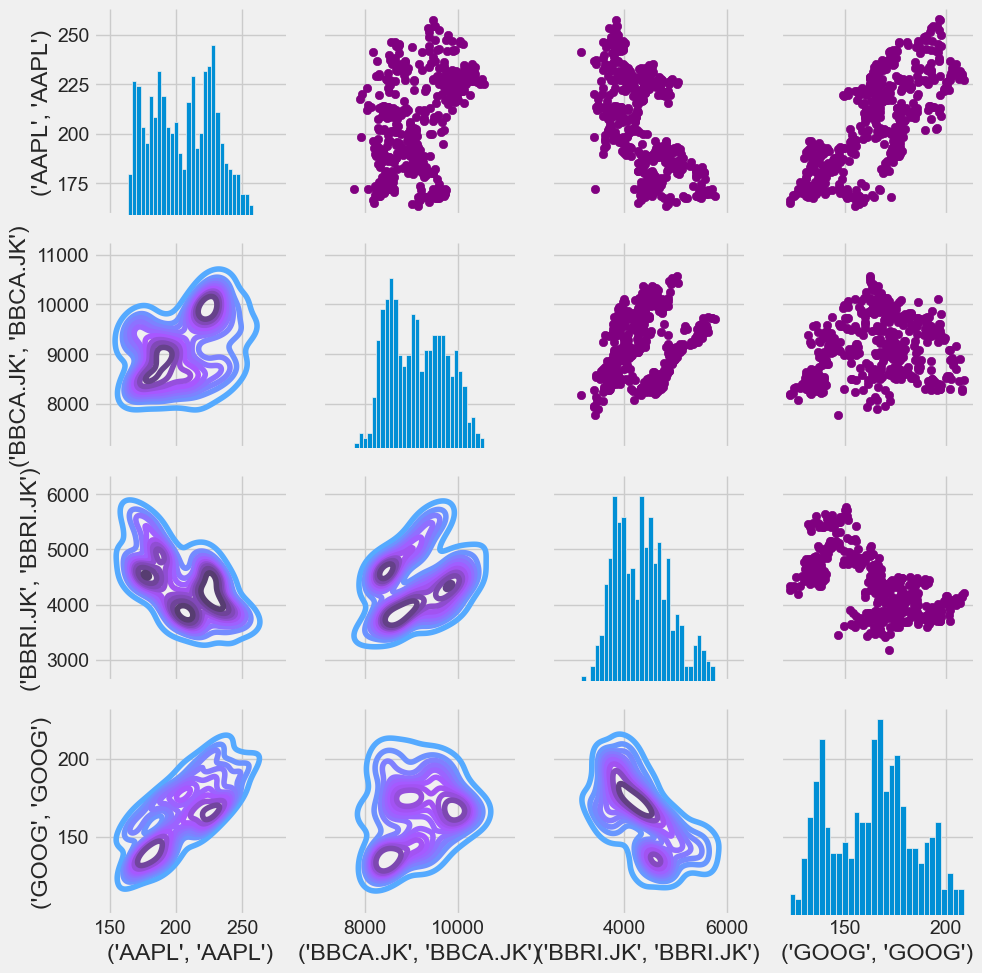

In [77]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
returns_fig = sns.PairGrid(closing_df)

# Using map_upper we can specify what the upper triangle will look like.
returns_fig.map_upper(plt.scatter,color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde) or the color map (BluePurple)
returns_fig.map_lower(sns.kdeplot,cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
returns_fig.map_diag(plt.hist,bins=30)

Text(0.5, 1.0, 'Correlation of stock closing price')

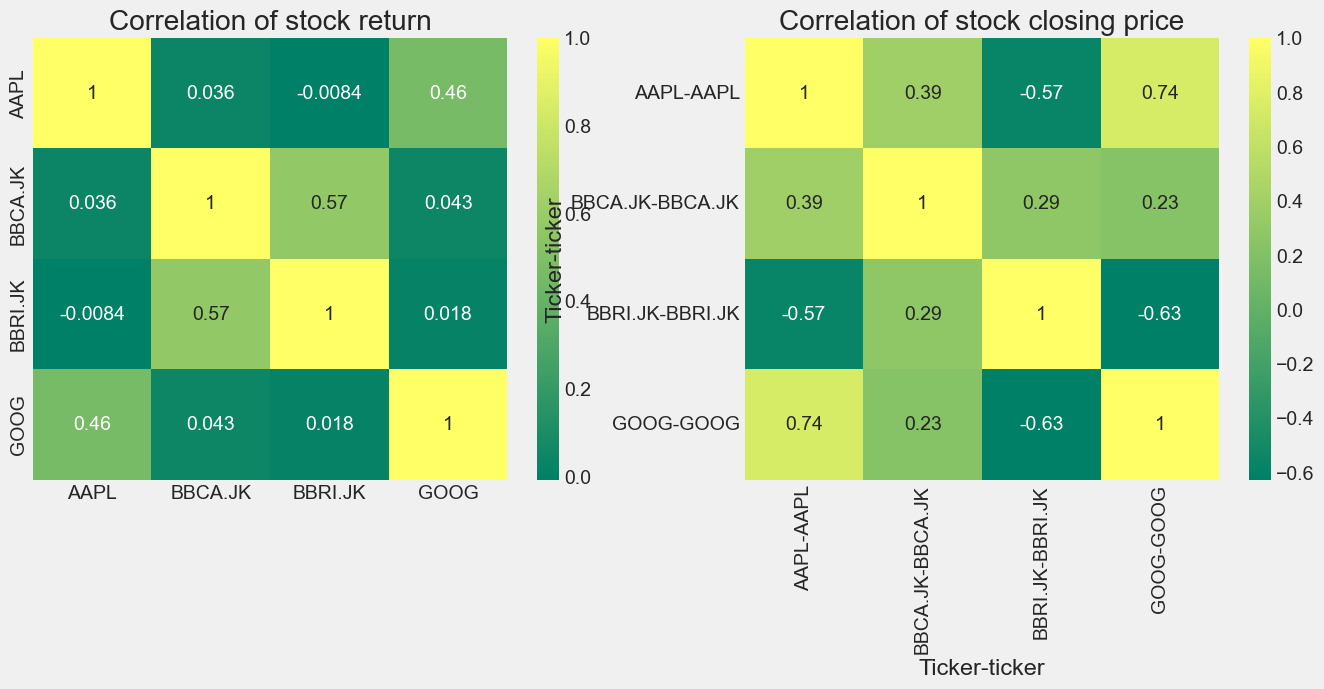

In [78]:
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
sns.heatmap(closing_rets.drop(columns='Date').corr(), annot=True, cmap='summer')
plt.title('Correlation of stock return')

plt.subplot(2, 2, 2)
sns.heatmap(closing_df.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock closing price')

from above we can see all the correlations on daily return beetween all the stocks. A quick glance shows an interesting correlation between BBCA and BBRI daily returns. It might be happening because they are both Indonesian stocks. as for apple and google, the correlation is not that strong.

from all the correlation that I do, heres what i found : 

1. Apple and Google correlation is positive but weak.

2. BBCA and BBRI correlation is positive and strong (this could happend because they are both Indonesian stocks)

3. all 4 stock are barely correlated, the line is flat, close to 0, which is almost not correlated to each other.



# 5 How much value do we put at risk by investing in a particular stock?

There are many ways we can quantify risk, and the most basic ways for doing that is using the information we've gathered on daily percentage returns is by comparing the expected return with the standard deviation of the daily returns.

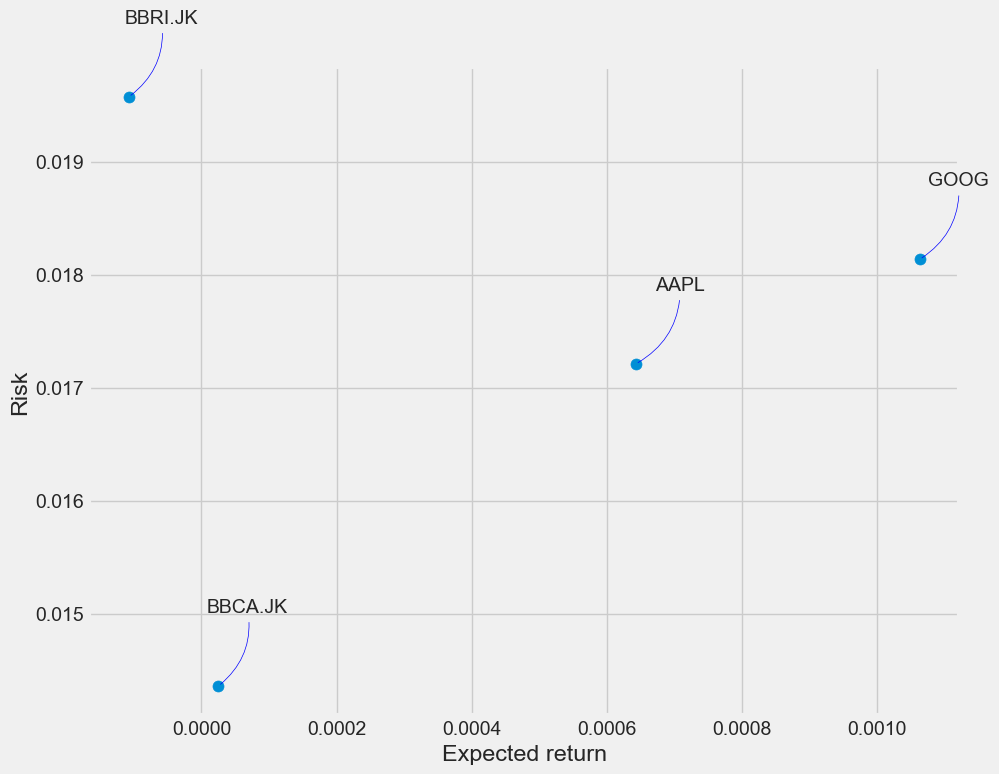

In [79]:
rets = closing_rets.drop(columns='Date').dropna()

area = np.pi * 20

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points', ha='right', va='bottom', 
                 arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))



from the graph above, we can see that : 

1. BBRI is the stock with the highest risk and lowest expected return. (not intresting)

2. BBCA is the most stable stock which is good for compounding.

3. AAPL is the stock  with moderate risk and good return (pretty good for attacking??).

4. GOOG is the stock with the highest risk and highest expected return.

GOOG/AAPL is the kind of stock you want to invest if you are planning on being aggressive and looking for high returns.

BBCA is the kind of stock you want to invest if you are planning on being conservative and looking for stable returns.

I would not go for BBRI because it has the highest risk and lowest expected return, i dont think it will provide any stability.

# 6. How can we attempt to predict future stock behavior? 

we are going to predict the stock price using machine learning algorithm. we are going to use LSTM (Long Short Term Memory) algorithm.
this algorithm usually used for time series prediction (where we want predict next value based on historical data which include time and date).





In [80]:
pred_df = yf.download('AAPL', start, end = end, auto_adjust=False)
pred_df 

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2023-08-28,178.442154,180.190002,180.589996,178.550003,180.089996,43820700
2023-08-29,182.334045,184.119995,184.899994,179.500000,179.699997,53003900
2023-08-30,185.829803,187.649994,187.850006,184.740005,184.940002,60813900
2023-08-31,186.047668,187.869995,189.119995,187.479996,187.839996,60794500
2023-09-01,187.622253,189.460007,189.919998,188.279999,189.490005,45766500
...,...,...,...,...,...,...
2025-08-21,224.899994,224.899994,226.520004,223.779999,226.270004,30621200
2025-08-22,227.759995,227.759995,229.089996,225.410004,226.169998,42477800


In [81]:
pred_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502 entries, 2023-08-28 to 2025-08-27
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  502 non-null    float64
 1   (Close, AAPL)      502 non-null    float64
 2   (High, AAPL)       502 non-null    float64
 3   (Low, AAPL)        502 non-null    float64
 4   (Open, AAPL)       502 non-null    float64
 5   (Volume, AAPL)     502 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 27.5 KB


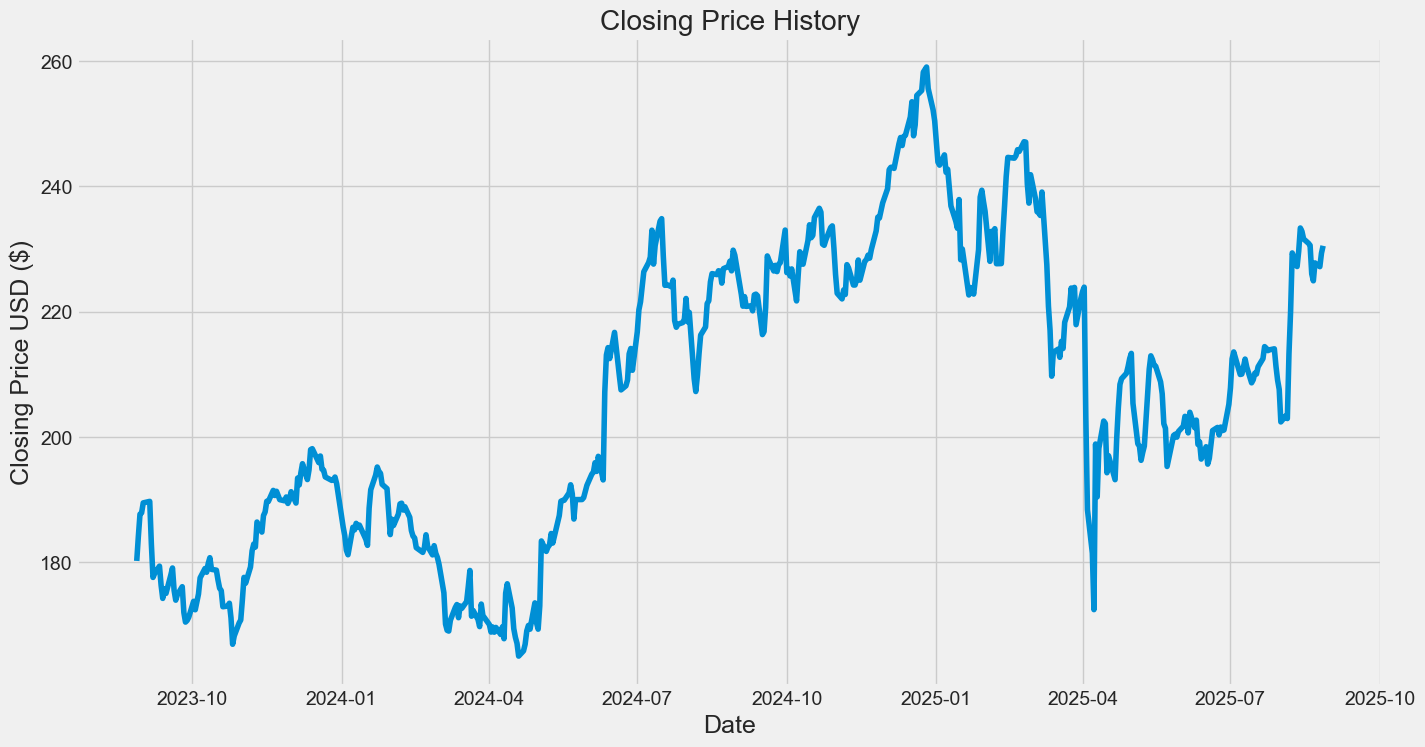

In [82]:
plt.figure(figsize=(15, 8))
plt.title('Closing Price History')
plt.plot(pred_df[('Close','AAPL')])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Closing Price USD ($)', fontsize=18)
plt.show()


In [83]:
# Create a new dataframe with only the 'Close column 
pred_dfs = pred_df['Close']['AAPL'].to_frame()

# Convert the dataframe to a numpy array
dataset = pred_dfs.values

# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

477

In [ ]:
# scale the data 

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.16156141],
       [0.20336096],
       [0.24090615],
       [0.24324609],
       [0.26015752],
       [0.26271006],
       [0.19049145],
       [0.13358859],
       [0.14018288],
       [0.15273349],
       [0.12018724],
       [0.09795796],
       [0.11423109],
       [0.10646666],
       [0.1379494 ],
       [0.14964911],
       [0.11157208],
       [0.09497972],
       [0.10412672],
       [0.1178473 ],
       [0.07402688],
       [0.0577536 ],
       [0.06051907],
       [0.06604986],
       [0.09306532],
       [0.0787066 ],
       [0.09210811],
       [0.10540316],
       [0.13284415],
       [0.1487982 ],
       [0.14241652],
       [0.15741337],
       [0.1670922 ],
       [0.14730917],
       [0.14592643],
       [0.12922777],
       [0.11529459],
       [0.11125301],
       [0.08381202],
       [0.08508829],
       [0.08976817],
       [0.06487989],
       [0.0201021 ],
       [0.03424805],
       [0.05626456],
       [0.06136997],
       [0.09540526],
       [0.133

In [85]:
# Create the scaled training data set

train_data = scaled_data[0:int(training_data_len), :]

# split data 
x_train= []
y_train = []

for i in range(60, len(train_data)) : 
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i <= 61 :
        print(x_train)
        print(y_train)
        print()

# convert the x_train and y_train to numpy array
x_train, y_train = np.array(x_train), np.array(y_train)

# reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_train.shape

[array([0.16156141, 0.20336096, 0.24090615, 0.24324609, 0.26015752,
       0.26271006, 0.19049145, 0.13358859, 0.14018288, 0.15273349,
       0.12018724, 0.09795796, 0.11423109, 0.10646666, 0.1379494 ,
       0.14964911, 0.11157208, 0.09497972, 0.10412672, 0.1178473 ,
       0.07402688, 0.0577536 , 0.06051907, 0.06604986, 0.09306532,
       0.0787066 , 0.09210811, 0.10540316, 0.13284415, 0.1487982 ,
       0.14241652, 0.15741337, 0.1670922 , 0.14730917, 0.14592643,
       0.12922777, 0.11529459, 0.11125301, 0.08381202, 0.08508829,
       0.08976817, 0.06487989, 0.0201021 , 0.03424805, 0.05626456,
       0.06136997, 0.09540526, 0.13369505, 0.12390976, 0.15135075,
       0.17889821, 0.19027868, 0.18517343, 0.22761111, 0.21059355,
       0.23867268, 0.24473513, 0.26281652, 0.26260376, 0.28132312])]
[np.float64(0.2727079598564943)]

[array([0.16156141, 0.20336096, 0.24090615, 0.24324609, 0.26015752,
       0.26271006, 0.19049145, 0.13358859, 0.14018288, 0.15273349,
       0.12018724, 0.097

(417, 60, 1)

In [86]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [87]:
# build model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# compile the modell
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

# train model
model.fit(x_train, y_train, batch_size=1, epochs=1)

d:\.vscode\kodingan\stock-prediction-project\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


417/417 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - loss: 0.0117


In [88]:
# create test data set
# create new array containing scaled values from index 1543 to 2002
test_data = scaled_data[training_data_len - 60 : , :]

# create the x_test and y_test data sets
x_test = []
y_test = dataset[training_data_len :, : ]


for i in range(60, len(test_data)) :
    x_test.append(test_data[i-60:i, 0])

# convert the data to a numpy array
x_test = np.array(x_test)

# reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# get the models predicted price values
predictions= model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100
rmse, mape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step


(np.float64(8.538660897717396), np.float64(2.8967464672431547))

C:\Users\ANGELO\AppData\Local\Temp\ipykernel_16164\4203062128.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


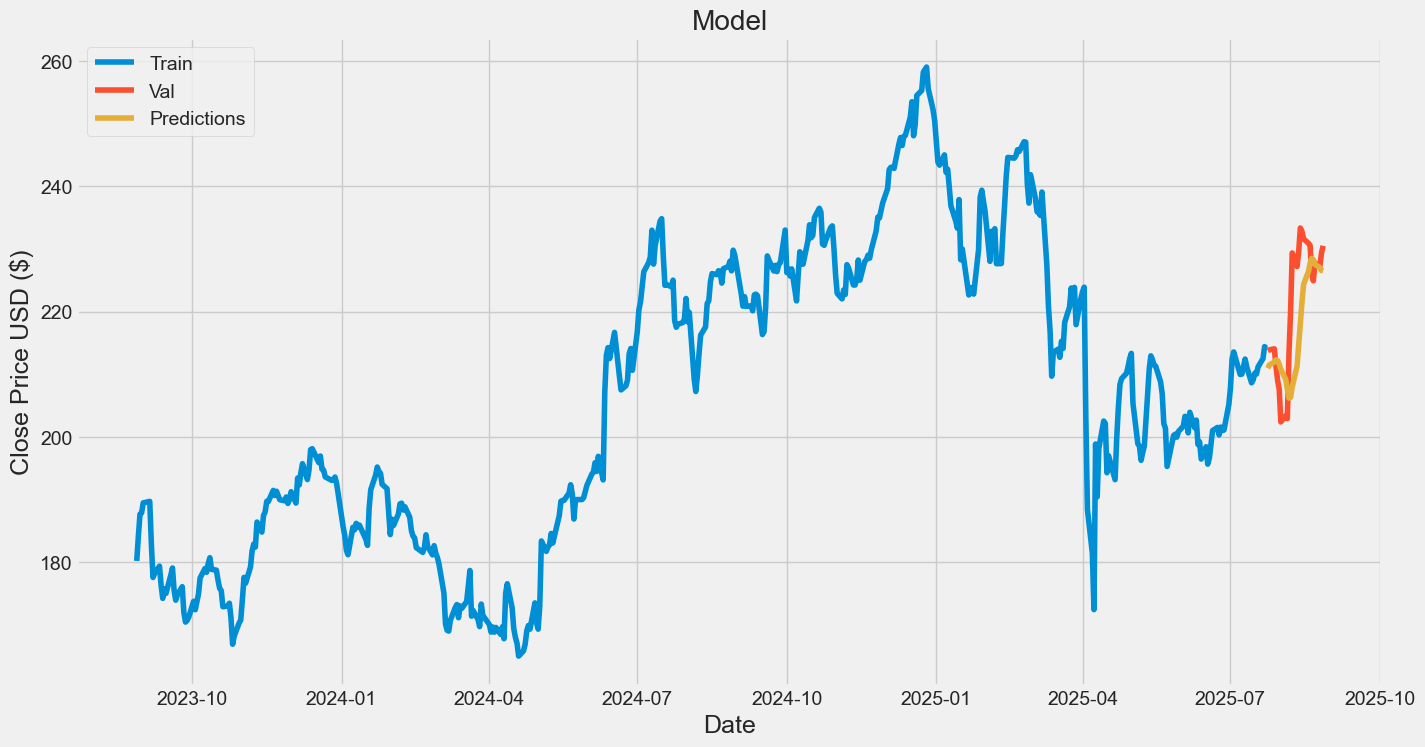

In [89]:
# Plot the data
train = pred_df[:training_data_len]
valid = pred_df[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(15,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close', 'AAPL'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='upper left')
plt.show()

In [90]:
valid

Price,Adj Close,Close,High,Low,Open,Volume,Predictions
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,,
2025-07-24,213.517670,213.759995,215.690002,213.529999,213.899994,46022600,210.943619
2025-07-25,213.637543,213.880005,215.240005,213.399994,214.699997,40268800,211.481964
2025-07-28,213.807358,214.050003,214.850006,213.059998,214.029999,37858000,211.916168
2025-07-29,211.030502,211.270004,214.809998,210.820007,214.179993,51411700,212.265762
2025-07-30,208.813019,209.050003,212.389999,207.720001,211.899994,45512500,212.177689
2025-07-31,207.334702,207.570007,209.839996,207.160004,208.490005,80698400,211.624908
2025-08-01,202.150589,202.380005,213.580002,201.500000,210.869995,104434500,210.742538
2025-08-04,203.119492,203.350006,207.880005,201.679993,204.509995,75109300,209.169312


# 7. Trying to predict the closing price for the next 2 days (AAPL)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Prediksi harga saham AAPL untuk 2025-08-28 00:00:00: 226.70904541015625
Prediksi harga saham AAPL untuk 2025-08-29 00:00:00: 226.58441162109375


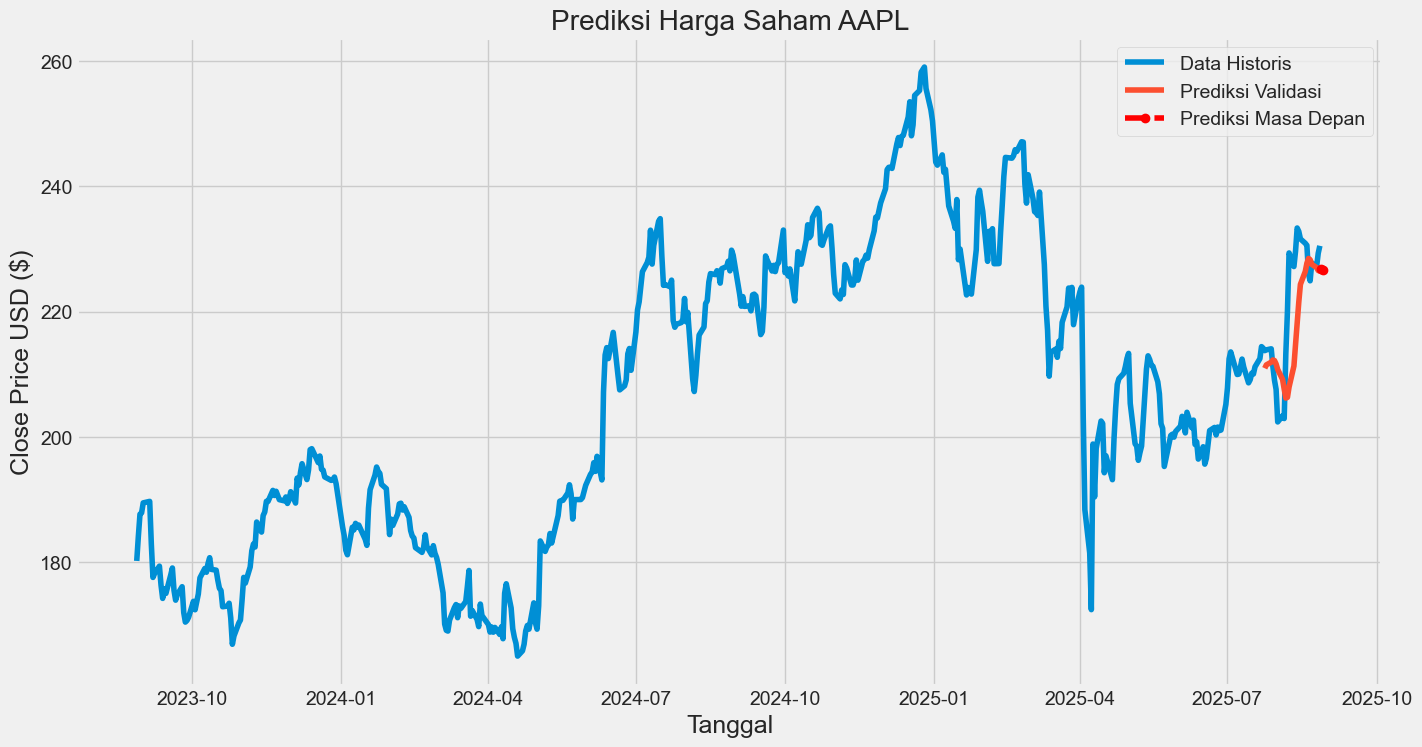

In [ ]:

# trying to predict the closing price for the next 2 days (28 & 29 Agustus 2025)

# get last 60 days from closing price data (real, not scaled)
last_60_days = pred_dfs[-60:].values  

# scale data
last_60_days_scaled = scaler.transform(last_60_days)

# copy for multi-step prediction process
temp_input = list(last_60_days_scaled.flatten())

future_predictions = []
future_dates = [datetime(2025, 8, 28), datetime(2025, 8, 29)]



for i in range(len(future_dates)):
    # get last 60 data
    X_test = np.array(temp_input[-60:]).reshape(1, 60, 1)

    # prediction
    pred_scaled = model.predict(X_test)
    pred_price = scaler.inverse_transform(pred_scaled)[0][0]

    # save result
    future_predictions.append(pred_price)

    # input the prediction into the window for the next step
    temp_input.append(pred_scaled[0][0])

# show the result
for d, p in zip(future_dates, future_predictions):
    print(f"Prediksi harga saham AAPL untuk {d}: {p}")

# --- Prediction Plot ---
plt.figure(figsize=(15,8))
plt.title('Prediksi Harga Saham AAPL')
plt.xlabel('Tanggal', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)

# histirical data plot
plt.plot(pred_df['Close']['AAPL'], label="Data Historis")

# val plot (actual vs prediction)
plt.plot(valid.index, valid['Predictions'], label="Prediksi Validasi")

# Prediction Plot for the future dates
plt.plot(future_dates, future_predictions, 'ro--', label="Prediksi Masa Depan")

plt.legend()
plt.show()


In [ ]:

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
# actual and predicted data
y_true = np.array([232.56, 232.14])
y_pred = np.array([226.7090, 226.5844])

# RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# MAPE
mape = mean_absolute_percentage_error(y_true, y_pred) * 100

print("RMSE (28-29 Agustus):", rmse)
print("MAPE (28-29 Agustus):", mape, "%")

RMSE (28-29 Agustus): 5.7052121941256475
MAPE (28-29 Agustus): 2.454560433043545 %


## Conclusion of Future Prediction for AAPL (August 28–29, 2025)

The LSTM model was applied to forecast Apple’s (AAPL) stock price for **August 28–29, 2025**.  

### Evaluation Results:
- **RMSE:** 5.7052  
- **MAPE:** 2.45%  

### Interpretation:
- With **MAPE below 5%**, the model demonstrates **good accuracy** in short-term stock price forecasting.  
- An **RMSE of about 5.7 USD** indicates that the average prediction error is relatively small compared to AAPL’s price level of around **230 USD**.  
- The model successfully follows the overall trend, with only minor deviations from the actual values.  

### Conclusion:
The model is **reliable for short-term predictions** of AAPL stock


# saving the model

since the model is trained for the AAPL stock, i will save the model as the AAPLstock_price_prediction_model.keras file to the models folder

In [99]:
model.save('../models/AAPLstock_price_prediction_model.keras')
print("Model saved to '../models/AAPLstock_price_prediction_model.keras'")

# closing_df.to_csv('../data/processed/closing_df.csv')

Model saved to '../models/AAPLstock_price_prediction_model.keras'


gosh this is hard,  i feel like i stepped into somthing that i hardly understand.